Paso 1: Configuración del Entorno de Trabajo
- Descripción: "Cargamos el stack de librerías esenciales para la manipulación masiva de datos y visualización estadística. Aseguramos un entorno preparado para procesar grandes volúmenes de registros de stock inicial."

In [1]:
# Importación de dependencias para análisis y gestión de archivos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración para gráficos integrados
%matplotlib inline

Paso 2: Ingesta del Inventario Inicial
- Descripción: "Importamos el dataset que contiene la fotografía del stock al comienzo del periodo fiscal 2016. Esta tabla es el punto de partida para calcular la rotación de inventario y las necesidades de reabastecimiento."

In [2]:
# Lectura de la fuente de datos original
df_inv_inicial = pd.read_csv("../data/BegInvFINAL12312016.csv", sep=',')

# Visualización del estado inicial de los datos
display(df_inv_inicial.head())

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2016-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2016-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2016-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2016-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2016-01-01


Paso 3: Auditoría Técnica del Dataset (Data Profiling)
- Descripción: "Implementamos una función de diagnóstico integral que genera un reporte detallado sobre la naturaleza de cada columna. Este análisis nos permite identificar de un vistazo los tipos de datos, la diversidad de valores y la presencia de vacíos (missing values)."

In [3]:
# Definición de la función de reporte de metadatos
def obtener_diagnostico_df(df):
    informe = pd.DataFrame(columns=['Columna', 'TipoDato', 'Total_Filas', 'Valores_Unicos', 'Nulos', 'Nulos_%'])
    
    for col in df.columns:
        # Extracción de métricas por variable
        tipo = df[col].dtype
        filas = df[col].shape[0]
        unicos = df[col].nunique()
        nulos = df[col].isnull().sum()
        pct_nulos = (nulos / len(df)) * 100
        
        # Consolidación en el DataFrame de reporte
        informe.loc[len(informe)] = [col, tipo, filas, unicos, nulos, np.round(pct_nulos, 4)]
        
    return informe

# Ejecución del diagnóstico sobre el inventario inicial
reporte_metadatos = obtener_diagnostico_df(df_inv_inicial)
display(reporte_metadatos)

,Columna,TipoDato,Total_Filas,Valores_Unicos,Nulos,Nulos_%
0,InventoryId,str,206529,206529,0,0.0
1,Store,int64,206529,79,0,0.0
2,City,str,206529,67,0,0.0
3,Brand,int64,206529,8094,0,0.0
4,Description,str,206529,7291,0,0.0
5,Size,str,206529,41,0,0.0
6,onHand,int64,206529,474,0,0.0
7,Price,float64,206529,329,0,0.0
8,startDate,str,206529,1,0,0.0


Paso 4: Verificación de Redundancia (Duplicados)
- Descripción: "Realizamos un control de integridad para asegurar que no existan SKU o registros de almacén repetidos. Garantizar la unicidad de las filas es vital para no inflar artificialmente el valor del activo en los libros contables."

In [4]:
# Validación de existencia de registros idénticos
existe_duplicidad = df_inv_inicial.duplicated().any()

if existe_duplicidad:
    print(f"Alerta: El dataset de Inventario Inicial presenta registros duplicados.")
else:
    print(f"Validación exitosa: No se detectaron redundancias en el inventario.")

Validación exitosa: No se detectaron redundancias en el inventario.


Paso 5: Análisis Exploratorio Univariado (EDA)
- Descripción: "Ejecutamos un barrido estadístico descriptivo para entender la composición del stock. Analizamos la distribución de cantidades, costos y la frecuencia de aparición de tiendas y marcas en el inventario de apertura."

In [5]:
# Iteración para obtener métricas descriptivas por cada dimensión
print("--- Resumen Estadístico por Variable ---")

for columna in df_inv_inicial.columns:
    print(f"\nAnálisis de: {columna}")
    # Usamos describe para obtener tendencia central y dispersión
    print(df_inv_inicial[columna].describe())
    print("-" * 30)

--- Resumen Estadístico por Variable ---

Análisis de: InventoryId
count                206529
unique               206529
top       1_HARDERSFIELD_58
freq                      1
Name: InventoryId, dtype: object
------------------------------

Análisis de: Store
count    206529.000000
mean         42.122457
std          23.191393
min           1.000000
25%          22.000000
50%          42.000000
75%          64.000000
max          79.000000
Name: Store, dtype: float64
------------------------------

Análisis de: City
count        206529
unique           67
top       MOUNTMEND
freq          14264
Name: City, dtype: object
------------------------------

Análisis de: Brand
count    206529.000000
mean      13761.482320
std       13059.429355
min          58.000000
25%        3746.000000
50%        8010.000000
75%       22143.000000
max       90090.000000
Name: Brand, dtype: float64
------------------------------

Análisis de: Description
count                   206529
unique            

Paso 6: Normalización de Nomenclatura (ETL)
- Descripción: "Estandarizamos los encabezados de la tabla para asegurar la compatibilidad con los módulos de Ventas y Compras ya procesados. Traducimos los términos técnicos al español para facilitar la interpretación del negocio."

In [6]:
# Mapeo integral de nombres para el inventario de apertura
renombrado_inv = {
    'InventoryId': 'Inventario_Inicial_ID',
    'Store': 'Tienda',
    'City': 'Ciudad',
    'Brand': 'Marca_ID',
    'Description': 'Descripcion',
    'Size': 'Tamaño',
    'onHand': 'Unidad_Disponible',
    'Price': 'Precio_Venta',
    'startDate': 'Fecha'
}

# Aplicación del cambio de forma persistente
df_inv_inicial.rename(columns=renombrado_inv, inplace=True)

# Verificación de la nueva estructura
display(df_inv_inicial.head())

,Inventario_Inicial_ID,Tienda,Ciudad,Marca_ID,Descripcion,Tamaño,Unidad_Disponible,Precio_Venta,Fecha
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2016-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2016-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2016-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2016-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2016-01-01


Paso 7: Ingeniería de Variables - Desglose de Unidades por Pack
- Descripción: "Identificamos los artículos que se presentan en formatos múltiples (Packs). Mediante expresiones regulares, extraemos el multiplicador numérico de la columna Tamaño para generar una nueva métrica de 'Cantidad' real de unidades, garantizando que un '6 Pk' se contabilice como 6 unidades y no como 1."

In [7]:
import re

# Lógica para la extracción de multiplicadores de empaque
def extraer_unidades_pack(texto_tamaño):
    # Buscamos patrones numéricos seguidos de 'Pk' (ej: 6 Pk, 12Pk)
    if 'Pk' in str(texto_tamaño):
        patron = re.search(r'(\d+)\s*Pk', str(texto_tamaño))
        if patron:
            return int(patron.group(1))
    return 1

# Creación de la columna 'Cantidad' basada en el análisis del formato
df_inv_inicial['Cantidad'] = df_inv_inicial['Tamaño'].apply(extraer_unidades_pack)

# Validación del proceso
print("Muestreo de productos con formato Pack y su conversión:")
display(df_inv_inicial[df_inv_inicial['Tamaño'].str.contains('Pk', na=False)].head())

Muestreo de productos con formato Pack y su conversión:


,Inventario_Inicial_ID,Tienda,Ciudad,Marca_ID,Descripcion,Tamaño,Unidad_Disponible,Precio_Venta,Fecha,Cantidad
116,1_HARDERSFIELD_1001,1,HARDERSFIELD,1001,Baileys 50mL 4 Pack,50mL 4 Pk,0,5.99,2016-01-01,4
118,1_HARDERSFIELD_1005,1,HARDERSFIELD,1005,Maker's Mark Combo Pack,375mL 2 Pk,7,34.99,2016-01-01,2
119,1_HARDERSFIELD_1006,1,HARDERSFIELD,1006,Jim Beam Candy Cane 4/50mLs,50mL 4 Pk,1,3.99,2016-01-01,4
120,1_HARDERSFIELD_1009,1,HARDERSFIELD,1009,Rebel Yell Variety Pack,750mL 3 Pk,1,49.99,2016-01-01,3
131,1_HARDERSFIELD_1031,1,HARDERSFIELD,1031,Avion Tasting Flight 3/375mL,375mL 3 Pk,5,49.99,2016-01-01,3


Paso 8: Análisis Geográfico de Disponibilidad
- Descripción: "Visualizamos la concentración de productos por ubicación física. Identificamos las 10 ciudades con mayor densidad de inventario inicial para entender los nodos logísticos principales de la operación."

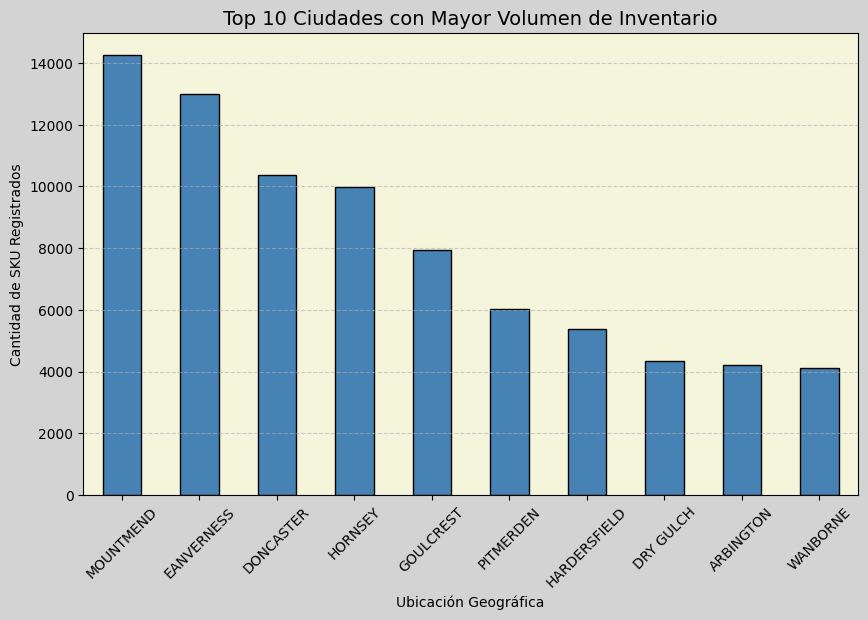

In [8]:
# Consolidación de existencias por nodo geográfico
ranking_ciudades = df_inv_inicial['Ciudad'].value_counts().nlargest(10)

# Generación del reporte visual de distribución
plt.figure(figsize=(10, 6), facecolor='lightgray')
ranking_ciudades.plot(kind='bar', color='steelblue', edgecolor='black')

plt.gca().set_facecolor('beige')
plt.title('Top 10 Ciudades con Mayor Volumen de Inventario', fontsize=14)
plt.xlabel('Ubicación Geográfica')
plt.ylabel('Cantidad de SKU Registrados')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Paso 9: Correlación de Variables de Stock
- Descripción: "Evaluamos la relación estadística entre las unidades disponibles, el precio de venta y la cantidad por pack. Este mapa de calor permite identificar si existe una tendencia de mayor stock en productos de menor precio o formatos específicos."

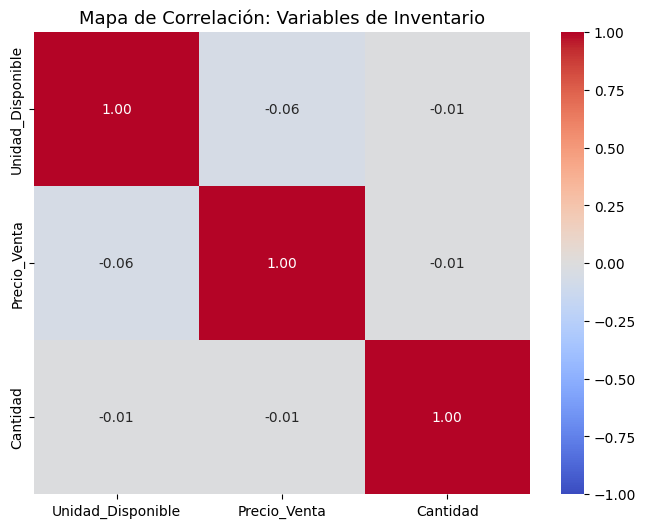

In [9]:
# Selección de dimensiones cuantitativas
columnas_numericas = ['Unidad_Disponible', 'Precio_Venta', 'Cantidad']

# Cálculo de la matriz de interdependencia
matriz_corr = df_inv_inicial[columnas_numericas].corr()

# Renderizado del mapa de calor térmico
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Mapa de Correlación: Variables de Inventario', fontsize=13)
plt.show()

Paso 10: Exportación del Inventario Inicial Saneado
- Descripción: "Finalizamos el flujo guardando el dataset con las nuevas unidades calculadas y los nombres estandarizados. Seguimos la regla de nomenclatura definida para los archivos limpios."

In [10]:
# Ruta de salida siguiendo la convención: Nombre_Limpios_Final.csv
ruta_final_inv_ini = "../data/DatosProcesados/Inventario_Inicial_Limpios_Final.csv"

# Persistencia en disco
df_inv_inicial.to_csv(ruta_final_inv_ini, index=False)

print(f"Sincronización completa: Archivo '{ruta_final_inv_ini}' generado con éxito.")

Sincronización completa: Archivo '../data/DatosProcesados/Inventario_Inicial_Limpios_Final.csv' generado con éxito.


Paso 11: Transformación a Modelo Dimensional (Split de Tablas)
- Descripción: "Segmentamos el dataset de inventario inicial para preparar las llaves temporales y espaciales. En este paso, estandarizamos el identificador de la tienda y vinculamos la fecha de registro al ID del calendario para asegurar la integridad referencial en el modelo estrella."

In [11]:
# --- GENERACIÓN DE DIMENSIONES ---

# 1. Dim_Tienda: Extraemos la sucursal y ciudad (Ya la generamos en el notebook de Inventario Final)
# Sin embargo, preparamos el DataFrame para asegurar consistencia
dim_tienda_ini = df_inv_inicial[['Tienda', 'Ciudad']].drop_duplicates().reset_index(drop=True)
dim_tienda_ini.rename(columns={'Tienda': 'Tienda_ID'}, inplace=True)

# 2. Dim_Calendario: Preparamos la vinculación temporal
# Convertimos la columna 'Fecha' (limpiada en Paso 8) a ID numérico AAAAMMDD
df_inv_inicial['Fecha_ID'] = pd.to_datetime(df_inv_inicial['Fecha']).dt.strftime('%Y%m%d').astype(int)

Paso 12: Construcción de la Tabla de Hechos (Fact_Inventario_Inicial)
- Descripción: "Estructuramos la tabla de hechos de inventario inicial. A diferencia del modelo operativo, aquí solo conservamos las llaves foráneas y las métricas de unidades disponibles, permitiendo un análisis eficiente de la evolución del stock a lo largo del año."

In [12]:
# Selección y renombrado de columnas para la Fact Table según el diagrama
fact_inv_inicial = df_inv_inicial[[
    'Inventario_Inicial_ID', # Se convertirá en Inventario_ID
    'Marca_ID',              # FK a Dim_Producto
    'Tienda',                # Se convertirá en Tienda_ID
    'Fecha_ID',              # FK a Dim_Calendario
    'Unidad_Disponible'      # Métrica de stock inicial
]].copy()

# Renombrado para coincidencia exacta con el diagrama y el inventario final
fact_inv_inicial.rename(columns={
    'Inventario_Inicial_ID': 'Inventario_ID',
    'Tienda': 'Tienda_ID',
    'Unidad_Disponible': 'Unidades_Disponibles'
}, inplace=True)

Paso 13: Exportación Final a la Carpeta de Ingesta
- Descripción: "Persistimos las tablas procesadas en la carpeta 'DatosIngesta'. Es fundamental que el nombre de las columnas y el formato de los datos coincidan con el inventario final para permitir la comparación de existencias mediante SQL y Power BI."

In [13]:
# Definición de la ruta de ingesta organizada
ruta_ingesta = "../data/DatosIngesta/"

# Exportación definitiva
# Nota: Puedes elegir guardar esto en un archivo separado o anexarlo si SQL lo requiere
fact_inv_inicial.to_csv(ruta_ingesta + "Fact_Inventario_Inicial.csv", index=False)

print(f"--- PROCESO DE SEGMENTACIÓN COMPLETADO ---")
print(f"Archivo generado en {ruta_ingesta}: Fact_Inventario_Inicial.csv")

--- PROCESO DE SEGMENTACIÓN COMPLETADO ---
Archivo generado en ../data/DatosIngesta/: Fact_Inventario_Inicial.csv
